# ----------------------------
# 1. Import Libraries
# ----------------------------

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----------------------------
# 2. Load Dataset
# ----------------------------

In [18]:
df = pd.read_csv("heart.csv.csv")   
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# ----------------------------
# 3. Exploratory Data Analysis
# ----------------------------

In [19]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.0

C:\Users\a\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


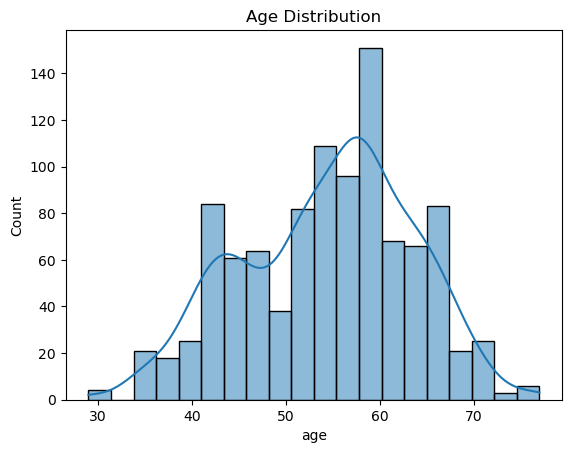

In [34]:
# Extra EDA plots
sns.histplot(df['age'], kde=True, bins=20)
plt.title('Age Distribution')
plt.show()

#sns.countplot(x='cp', hue='target', data=df, palette='Set1')
#plt.title('Chest Pain Type vs Heart Disease')
#plt.show()

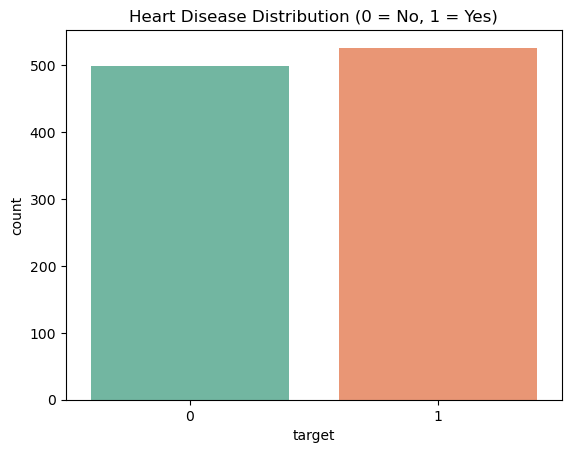

In [20]:
# Target distribution
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()

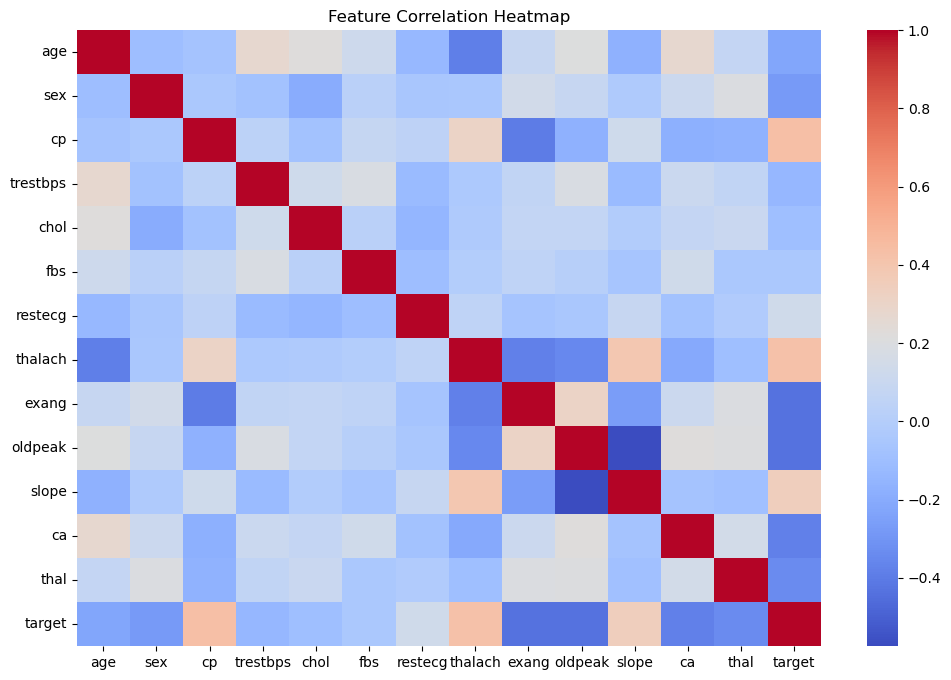

In [21]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ----------------------------
# 4. Data Preprocessing
# ----------------------------

In [22]:
X = df.drop("target", axis=1)
y = df["target"]

In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (820, 13)
Testing data shape: (205, 13)


# ----------------------------
# 5. Model Training
# ----------------------------

In [25]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

In [26]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# ----------------------------
# 6. Evaluation
# ----------------------------

In [27]:
models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
   # "SVM": y_pred_svm
}


📌 Logistic Regression
Accuracy: 0.8097560975609757
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



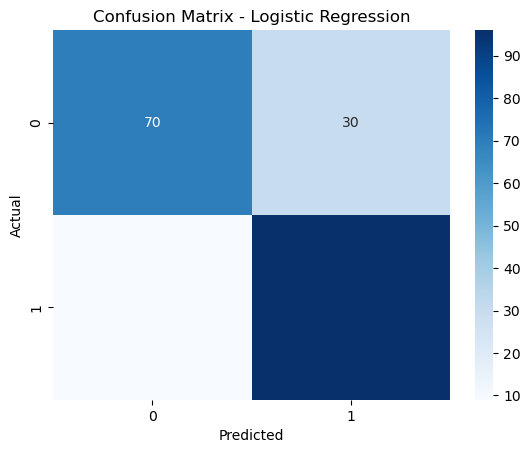


📌 Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



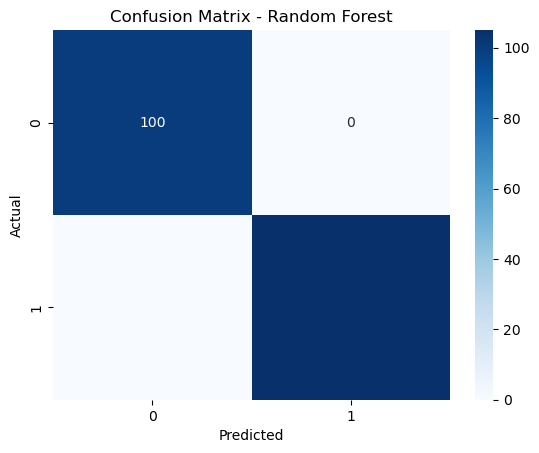

In [28]:
for model, preds in models.items():
    print(f"\n📌 {model}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ----------------------------
# 7. Feature Importance (from Random Forest)
# ----------------------------

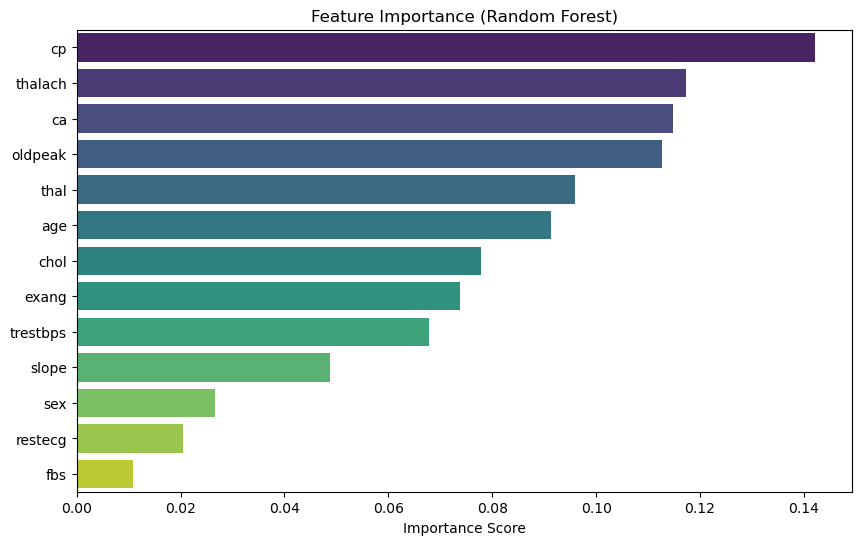

In [29]:
importances = rf.feature_importances_
features = df.drop("target", axis=1).columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

# ----------------------------
# 8. Conclusion
# ----------------------------

In [30]:
print("✅ Project Completed")
print("Best model usually is Random Forest (check accuracies above).")
print("Top features influencing prediction shown in importance plot.")

✅ Project Completed
Best model usually is Random Forest (check accuracies above).
Top features influencing prediction shown in importance plot.
